# 26 — Asthma × Diabetes: Pulmonary Disease & Glycemic Control

**Purpose**: Characterize the relationship between chronic pulmonary disease (asthma/COPD/emphysema)
and diabetes management in the AI-READI cohort. Specifically: (1) prevalence of pulmonary disease
across diabetes severity groups, (2) comorbidity burden in pulmonary patients, (3) HbA1c and CGM
comparisons between pulmonary vs non-pulmonary patients stratified by diabetes stage, and (4)
SDoH burden in the pulmonary-diabetic intersection.

> **Critical limitation**: The AI-READI dataset does not have a dedicated asthma flag.
> The item used here — `mhoccur_plm` — is a bundled binary flag covering asthma, COPD,
> and emphysema. In adults aged 40+, COPD likely contributes substantially to this group.
> All findings should be interpreted as applying to *chronic pulmonary disease broadly*,
> with asthma as a major but unquantifiable component. This is stated at each analysis.

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year of birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — mhoccur flags + SDoH surveys
- Azure `{STUDY_ID}/dataset/clinical_data/measurement.csv` — HbA1c (`import_hba1c`) + CGM

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. Build Master DataFrame
4. Analysis 1 — Pulmonary Prevalence by Diabetes Severity
5. Analysis 2 — Comorbidity Enrichment in Pulmonary Patients
6. Analysis 3 — HbA1c by Pulmonary Status × Diabetes Group
7. Analysis 4 — CGM Metrics by Pulmonary Status
8. Analysis 5 — Age-Stratified Patterns
9. Analysis 6 — SDoH / Psychosocial Burden
10. Key Findings

---

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, re, warnings, getpass, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}

AGE_BINS   = [40, 55, 70, 80, 120]
AGE_LABELS = ['40–54', '55–69', '70–79', '80+']
AGE_ORDER  = AGE_LABELS

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'

# Color scheme: orange/blue for pulmonary vs non-pulmonary
PLM_COLORS   = {'Non-Pulmonary': '#4C72B0', 'Pulmonary': '#DD8452'}
PLM_ORDER    = ['Non-Pulmonary', 'Pulmonary']
GROUP_COLORS = sns.color_palette('Set2', 4)

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection & Data Load ──────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
    STUDY_ID       = '1438dd73-c4cb-48b8-8fa8-c858771207c3'
else:
    _cwd = Path.cwd()
    if (_cwd / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd)
    elif (_cwd.parent / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd.parent)
    else:
        repo_root = str(_cwd)

    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)

    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)

    print(f'.env path : {_env_path}  (found={_env_path.exists()})')
    print(f'repo_root : {repo_root}')
    print(f'Container : {CONTAINER_NAME}')
    print(f'Study ID  : {STUDY_ID}')

    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING is empty — check your .env file')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV/TSV directly from Azure Blob into a DataFrame."""
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

# ── Load participants ─────────────────────────────────────────────
print('\nLoading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

# ── Load person (age) ─────────────────────────────────────────────
print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age']       = 2024 - person['year_of_birth']
person['age_group'] = pd.cut(person['age'], bins=AGE_BINS, labels=AGE_LABELS, right=False)
person['age_group'] = pd.Categorical(person['age_group'], categories=AGE_ORDER, ordered=True)
print(f'  {len(person):,} persons  |  age range: {person["age"].min()}–{person["age"].max()}')

# ── Load observation (mhoccur flags + SDoH surveys) ──────────────
print('\nLoading observation.csv (~108 MB) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'  {len(obs_raw):,} rows × {obs_raw.shape[1]} cols')

# ── Load measurement (HbA1c + CGM) ──────────────────────────────
print('\nLoading measurement.csv (~108 MB) ...')
meas = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/measurement.csv')
print(f'  {len(meas):,} rows × {meas.shape[1]} cols')

.env path : /Users/evanlee/Desktop/ucsf-tech-aireadi/.env  (found=True)
repo_root : /Users/evanlee/Desktop/ucsf-tech-aireadi
Container : aireadi-container
Study ID  : 1438dd73-c4cb-48b8-8fa8-c858771207c3

Loading participants.tsv ...
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...
  2,280 persons  |  age range: 41–94

Loading observation.csv (~108 MB) ...
  707,126 rows × 22 cols

Loading measurement.csv (~108 MB) ...
  242,279 rows × 26 cols


In [3]:
# ── 3. Build Master DataFrame ────────────────────────────────────

# ── 3a. Parse mhoccur items from observation.csv ──────────────────
obs_raw['item_key']    = (obs_raw['observation_source_value']
                          .astype(str).str.split(',', n=1).str[0]
                          .str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan

mh_obs = obs_raw[obs_raw['item_key'].str.startswith('mhoccur', na=False)].copy()
print(f'mhoccur rows: {len(mh_obs):,}  |  unique items: {mh_obs["item_key"].nunique()}')

# Build human-readable label map
def clean_label(s):
    if not isinstance(s, str): return str(s)
    s = re.sub(
        r'^(Do you (currently )?have |Have you (ever )?had |'
        r'Have you been (told by a doctor |diagnosed )|'
        r'You have been diagnosed with )',
        '', s, flags=re.IGNORECASE).strip()
    s = s.rstrip('?').strip()
    return s[:1].upper() + s[1:] if s else s

label_map_raw = (mh_obs[['item_key', 'observation_source_value']]
                 .drop_duplicates('item_key')
                 .assign(desc=lambda d: d['observation_source_value']
                                         .str.split(',', n=1).str[1]
                                         .str.strip()))
label_map = dict(zip(label_map_raw['item_key'],
                     label_map_raw['desc'].apply(clean_label)))

# Pivot to wide
mh_wide = (mh_obs[['person_id', 'item_key', 'value_clean']]
           .pivot_table(index='person_id', columns='item_key',
                        values='value_clean', aggfunc='first')
           .clip(upper=1))

disease_cols = [c for c in mh_wide.columns if 'fallot' not in c]
mh_wide = mh_wide[disease_cols]

# ── 3b. Confirm mhoccur_plm exists and inspect ────────────────────
if 'mhoccur_plm' not in mh_wide.columns:
    raise ValueError('mhoccur_plm not found — check observation_source_value encoding')

plm_label = label_map.get('mhoccur_plm', 'Chronic pulmonary (lung) problems')
print(f'\nPulmonary flag: mhoccur_plm → "{plm_label}"')

# ── 3c. Extract SDoH / psychosocial items ────────────────────────
# AI-READI scales: CES-D-10 total (cestl), perceived discrimination (pxrd*),
# food insecurity (pxfi*), housing instability (pxhi*).
# Note: phq/ssq/fsq do NOT exist in this dataset.
SDOH_PREFIXES = ('ces', 'pxrd', 'pxfi', 'pxhi', 'paid', 'pdrx')
sdoh_obs = obs_raw[obs_raw['item_key'].str.startswith(SDOH_PREFIXES, na=False)].copy()

# CES-D-10: stored as a single total-score item 'cestl'
cesd_items = [k for k in sdoh_obs['item_key'].unique() if k.startswith('cestl') or
              (k.startswith('ces') and not k.endswith('metadata'))]

# Discrimination stress: pxrd* items with "stressful" wording (numbered multiples of 3)
pxrd_stress_items = [k for k in sdoh_obs['item_key'].unique()
                     if re.match(r'pxrd\d+$', k)]

# Food insecurity: pxfi* items
food_items = [k for k in sdoh_obs['item_key'].unique() if k.startswith('pxfi')]

# Housing instability: pxhi* items (binary: stable/unstable)
housing_items = [k for k in sdoh_obs['item_key'].unique()
                 if k.startswith('pxhi') and not k.endswith('metadata')]

def score_scale(obs_df, items, col_name):
    # Named-index empty Series so reset_index() yields 'person_id' column, not 'index'.
    if not items:
        return pd.Series(dtype=float, name=col_name).rename_axis('person_id')
    sub = obs_df[obs_df['item_key'].isin(items)]
    wide = sub.pivot_table(index='person_id', columns='item_key',
                           values='value_clean', aggfunc='mean')
    return wide.sum(axis=1, min_count=1).rename(col_name)

cesd_scores    = score_scale(sdoh_obs, cesd_items,       'cesd_total')
discrim_scores = score_scale(sdoh_obs, pxrd_stress_items,'discrim_stress')
food_scores    = score_scale(sdoh_obs, food_items,       'food_insecurity')
housing_scores = score_scale(sdoh_obs, housing_items,    'housing_score')

print(f'CES-D items found  : {cesd_items}  → {cesd_scores.notna().sum():,} patients')
print(f'Discrimination items: {len(pxrd_stress_items)}  → {discrim_scores.notna().sum():,} patients')
print(f'Food insecurity items: {len(food_items)}  → {food_scores.notna().sum():,} patients')
print(f'Housing items       : {len(housing_items)}  → {housing_scores.notna().sum():,} patients')

# ── 3d. Extract HbA1c from measurement.csv ───────────────────────
# 'lbscat_a1c' = CBC hemoglobin (g/dL) — NOT HbA1c. Correct HbA1c = 'import_hba1c'.
hba1c_mask = meas['measurement_source_value'].astype(str).str.lower().str.contains(
    'import_hba1c', na=False)
hba1c_concepts = {4184637, 3004410, 3005673, 40758583}
concept_mask = meas['measurement_concept_id'].isin(hba1c_concepts) \
    if 'measurement_concept_id' in meas.columns else pd.Series(False, index=meas.index)

hba1c_raw = meas[hba1c_mask | concept_mask].copy()
hba1c_raw['value'] = pd.to_numeric(hba1c_raw['value_as_number'], errors='coerce')
hba1c_raw = hba1c_raw[(hba1c_raw['value'] >= 3) & (hba1c_raw['value'] <= 20)]

if 'measurement_date' in hba1c_raw.columns:
    hba1c_raw['measurement_date'] = pd.to_datetime(hba1c_raw['measurement_date'], errors='coerce')
    hba1c_raw = hba1c_raw.sort_values('measurement_date')

hba1c_per_person = (hba1c_raw.groupby('person_id')['value']
                    .last().rename('hba1c'))
print(f'\nHbA1c: {len(hba1c_per_person):,} patients  '
      f'| mean={hba1c_per_person.mean():.1f}%  '
      f'| range={hba1c_per_person.min():.1f}–{hba1c_per_person.max():.1f}%')

# ── 3e. Extract CGM metrics ──────────────────────────────────────
# CGM readings live in wearable_blood_glucose/manifest.tsv, NOT measurement.csv.
# Detailed TIR/CV% come from notebook 17's output file if available locally.
print('Loading CGM manifest from Azure ...')
try:
    cgm_manifest = load_blob_csv(f'{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv', sep='\t')
    cgm_manifest.columns = cgm_manifest.columns.str.strip().str.lower()
    _mean_col = next((c for c in cgm_manifest.columns if 'average_glucose' in c), None)
    if _mean_col:
        cgm_manifest = cgm_manifest.rename(columns={_mean_col: 'mean_glucose'})
    cgm_manifest['mean_glucose'] = pd.to_numeric(cgm_manifest['mean_glucose'], errors='coerce')
    cgm_manifest['gmi'] = (3.31 + 0.02392 * cgm_manifest['mean_glucose']).round(2)
    print(f'  {len(cgm_manifest):,} participants in CGM manifest')
except Exception as _e:
    print(f'  Manifest load failed: {_e}')
    cgm_manifest = pd.DataFrame(columns=['person_id', 'mean_glucose', 'gmi'])

# Try to load pre-computed TIR / CV% from notebook 17 output.
# NB17 saves to Google Drive: ORGANIZATIONS/ucsftech_outputs/17_spike_metrics_per_person.csv
# Running in VSCode? Download that file from Drive and place it in the project root.
_spike_paths = [
    Path(repo_root) / '17_spike_metrics_per_person.csv',
    Path(repo_root) / 'notebooks' / '17_spike_metrics_per_person.csv',
    Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs/17_spike_metrics_per_person.csv'),
]
spike_df = None
print('  Searching for 17_spike_metrics_per_person.csv ...')
for _sp in _spike_paths:
    print(f'    {_sp}  ->  exists={Path(str(_sp)).exists()}')
    if Path(str(_sp)).exists():
        spike_df = pd.read_csv(str(_sp))
        spike_df.columns = spike_df.columns.str.strip().str.lower()
        print(f'  Loaded from: {_sp}  ({len(spike_df):,} rows, cols: {spike_df.columns.tolist()[:8]})')
        break

if spike_df is None:
    # ── Inline fallback: stream Dexcom G6 JSONs from Azure ────────
    # Runs once (~10–15 min); result cached to 17_spike_metrics_per_person.csv.
    _cache_path = Path(repo_root) / '17_spike_metrics_per_person.csv'
    print('  Computing TIR and CV% from Azure Dexcom G6 JSON files ...')
    print(f'  Result will be cached to: {_cache_path}')
    print('  (≈10–15 min first run; subsequent runs load instantly)')

    def _parse_dexcom_json(raw_bytes):
        """Adapted from notebook 17. Returns glucose array or None."""
        try:
            data = json.loads(raw_bytes.decode('utf-8'))
        except Exception:
            return None
        readings = None
        if isinstance(data, dict):
            body = data.get('body', {})
            if isinstance(body, dict) and 'cgm' in body:
                readings = body['cgm']
        if readings is None:
            if isinstance(data, list):
                readings = data
            elif isinstance(data, dict):
                for key in ['Readings', 'readings', 'egvs', 'data']:
                    if key in data and isinstance(data[key], list):
                        readings = data[key]; break
        if not isinstance(readings, list) or len(readings) < 12:
            return None
        vals = []
        for r in readings:
            if not isinstance(r, dict): continue
            val = None
            bg = r.get('blood_glucose')
            if isinstance(bg, dict): val = bg.get('value')
            if val is None:
                val = (r.get('value') or r.get('Value') or
                       r.get('glucose') or r.get('GlucoseValue'))
            try:
                v = float(val)
                if 40 <= v <= 400: vals.append(v)
            except (TypeError, ValueError):
                pass
        return np.array(vals) if len(vals) >= 12 else None

    _spike_records = []
    _first_error   = None   # capture first failure for diagnosis
    _first_none    = None   # capture first parse→None case

    print(f'  Manifest columns: {cgm_manifest.columns.tolist()}')

    if 'glucose_filepath' not in cgm_manifest.columns:
        print('  glucose_filepath column missing — cannot compute inline.')
    else:
        # Verify first path before full loop
        _test_row   = cgm_manifest.iloc[0]
        _test_path  = f"{STUDY_ID}/dataset{_test_row['glucose_filepath']}"
        print(f'  Sample blob path: {_test_path}')
        try:
            _test_raw = container.get_blob_client(_test_path).download_blob().readall()
            print(f'  Test blob OK: {len(_test_raw):,} bytes')
            _test_arr = _parse_dexcom_json(_test_raw)
            if _test_arr is not None:
                print(f'  Test parse OK: {len(_test_arr)} readings, mean={_test_arr.mean():.1f}')
            else:
                # Show raw JSON structure to diagnose parser mismatch
                _sample = json.loads(_test_raw.decode('utf-8'))
                if isinstance(_sample, dict):
                    print(f'  Parse returned None. JSON top-level keys: {list(_sample.keys())[:6]}')
                    body = _sample.get('body', {})
                    if isinstance(body, dict):
                        print(f'  body keys: {list(body.keys())[:6]}')
                elif isinstance(_sample, list):
                    print(f'  JSON is a list of {len(_sample)} items. First item keys: {list(_sample[0].keys())[:6] if _sample else []}')
        except Exception as _te:
            print(f'  Test blob FAILED: {_te}')

        for _i, _mrow in cgm_manifest.iterrows():
            _pid      = str(_mrow['person_id'])
            _blobpath = f"{STUDY_ID}/dataset{_mrow['glucose_filepath']}"
            try:
                _raw  = container.get_blob_client(_blobpath).download_blob().readall()
                _arr  = _parse_dexcom_json(_raw)
                if _arr is not None:
                    _spike_records.append({
                        'person_id': _pid,
                        'tir':        float(((_arr >= 70) & (_arr <= 180)).mean() * 100),
                        'glucose_cv': float(_arr.std() / _arr.mean() * 100),
                    })
                elif _first_none is None:
                    _first_none = _pid
            except Exception as _ex:
                if _first_error is None:
                    _first_error = f'{_pid}: {type(_ex).__name__}: {_ex}'
            if (_i + 1) % 200 == 0:
                print(f'    {_i+1}/{len(cgm_manifest)} done ({len(_spike_records)} parsed) ...')
                if _first_error:
                    print(f'    First error: {_first_error}')
                if _first_none:
                    print(f'    First parse→None pid: {_first_none}')

        if _spike_records:
            spike_df = pd.DataFrame(_spike_records)
            spike_df['person_id'] = spike_df['person_id'].astype(str)
            spike_df.to_csv(str(_cache_path), index=False)
            print(f'  Done: {len(spike_df):,} patients. Cached to {_cache_path.name}')
        else:
            print(f'  0 parsed.  first_error={_first_error}  first_none={_first_none}')


cgm_metrics = cgm_manifest[['person_id', 'mean_glucose', 'gmi']].copy()
if spike_df is not None and 'person_id' in spike_df.columns:
    # NB17 exports 'glucose_cv' and 'tir' — standardise cv name for this notebook
    _rename = {}
    if 'glucose_cv' in spike_df.columns: _rename['glucose_cv'] = 'cv_glucose'
    if 'glucose_sd' in spike_df.columns: _rename['glucose_sd'] = 'std_glucose'
    spike_sub = spike_df.rename(columns=_rename)
    # Normalise person_id dtype so int64 (manifest) and str (spike file) merge cleanly
    cgm_metrics['person_id'] = cgm_metrics['person_id'].astype(str)
    spike_sub['person_id']   = spike_sub['person_id'].astype(str)
    _extra = [c for c in ['cv_glucose', 'tir'] if c in spike_sub.columns]
    if _extra:
        cgm_metrics = cgm_metrics.merge(spike_sub[['person_id'] + _extra], on='person_id', how='left')
    else:
        print(f'  cv_glucose/tir not found in spike file cols: {spike_sub.columns.tolist()}')

# Restore person_id to int64 so it matches base/participants (int64)
cgm_metrics['person_id'] = pd.to_numeric(cgm_metrics['person_id'], errors='coerce').astype('Int64')
print(f'CGM metrics: {len(cgm_metrics):,} patients  |  cols: {cgm_metrics.columns.tolist()}')

# ── 3f. Merge everything into master DataFrame ────────────────────
base = (participants[['person_id', 'study_group_code', 'study_group_label']]
        .merge(person[['person_id', 'age', 'age_group']], on='person_id', how='left'))

df = (base
      .merge(mh_wide[disease_cols].reset_index(), on='person_id', how='left')
      .merge(hba1c_per_person.reset_index(), on='person_id', how='left')
      .merge(cgm_metrics[[c for c in ['person_id','mean_glucose','cv_glucose','tir','gmi']
                    if c in cgm_metrics.columns]], on='person_id', how='left')
      .merge(cesd_scores.reset_index(),    on='person_id', how='left')
      .merge(discrim_scores.reset_index(), on='person_id', how='left')
      .merge(food_scores.reset_index(),    on='person_id', how='left')
      .merge(housing_scores.reset_index(), on='person_id', how='left'))

df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
df['age_group'] = pd.Categorical(
    df['age_group'], categories=AGE_ORDER, ordered=True)

# Binary pulmonary flag + readable label
df['pulmonary']       = df['mhoccur_plm'].fillna(0).astype(int)
df['pulmonary_label'] = df['pulmonary'].map({1: 'Pulmonary', 0: 'Non-Pulmonary'})
df['pulmonary_label'] = pd.Categorical(
    df['pulmonary_label'], categories=PLM_ORDER, ordered=True)

print(f'\nMaster df: {df.shape[0]:,} participants × {df.shape[1]} columns')
print('\nPulmonary prevalence overall:')
print(df['pulmonary_label'].value_counts())
plm_pct = df['pulmonary'].mean() * 100
print(f'  → {plm_pct:.1f}% of cohort has chronic pulmonary condition')

mhoccur rows: 66,486  |  unique items: 30

Pulmonary flag: mhoccur_plm → "Chronic pulmonary (lung) problems (E"
CES-D items found  : ['ces9', 'cesmpdat', 'cesstartts', 'ces1', 'ces2', 'ces3', 'ces4', 'ces5', 'ces6', 'ces7', 'ces8', 'ces10', 'cestl']  → 2,279 patients
Discrimination items: 53  → 2,280 patients
Food insecurity items: 6  → 2,280 patients
Housing items       : 9  → 2,063 patients

HbA1c: 2,211 patients  | mean=6.1%  | range=3.8–17.0%
Loading CGM manifest from Azure ...
  2,245 participants in CGM manifest
  Searching for 17_spike_metrics_per_person.csv ...
    /Users/evanlee/Desktop/ucsf-tech-aireadi/17_spike_metrics_per_person.csv  ->  exists=True
  Loaded from: /Users/evanlee/Desktop/ucsf-tech-aireadi/17_spike_metrics_per_person.csv  (2,243 rows, cols: ['person_id', 'tir', 'glucose_cv'])
CGM metrics: 2,245 patients  |  cols: ['person_id', 'mean_glucose', 'gmi', 'cv_glucose', 'tir']

Master df: 2,280 participants × 45 columns

Pulmonary prevalence overall:
pulmonary_label

---
## 4. Analysis 1 — Pulmonary Prevalence by Diabetes Severity

> **Question**: Is chronic pulmonary disease more prevalent at advanced diabetes stages?
>
> **Literature anchor**: Obesity mediates ~30% of the asthma-T2DM association (GBD 2019);
> insulin resistance and systemic inflammation are shared mechanisms. We expect higher pulmonary
> prevalence in Oral Med and Insulin groups.
>
> **Note**: `mhoccur_plm` captures asthma + COPD + emphysema combined.

Chi-squared test (4 groups vs pulmonary): χ²=9.32, df=3, p=0.0253

Pairwise vs Healthy (Fisher exact, Bonferroni corrected):
  Healthy vs Pre-DM     p_raw=0.4935  p_adj=1.0000  ns
  Healthy vs Oral Med   p_raw=0.0206  p_adj=0.0618  ns
  Healthy vs Insulin    p_raw=0.0135  p_adj=0.0405  *


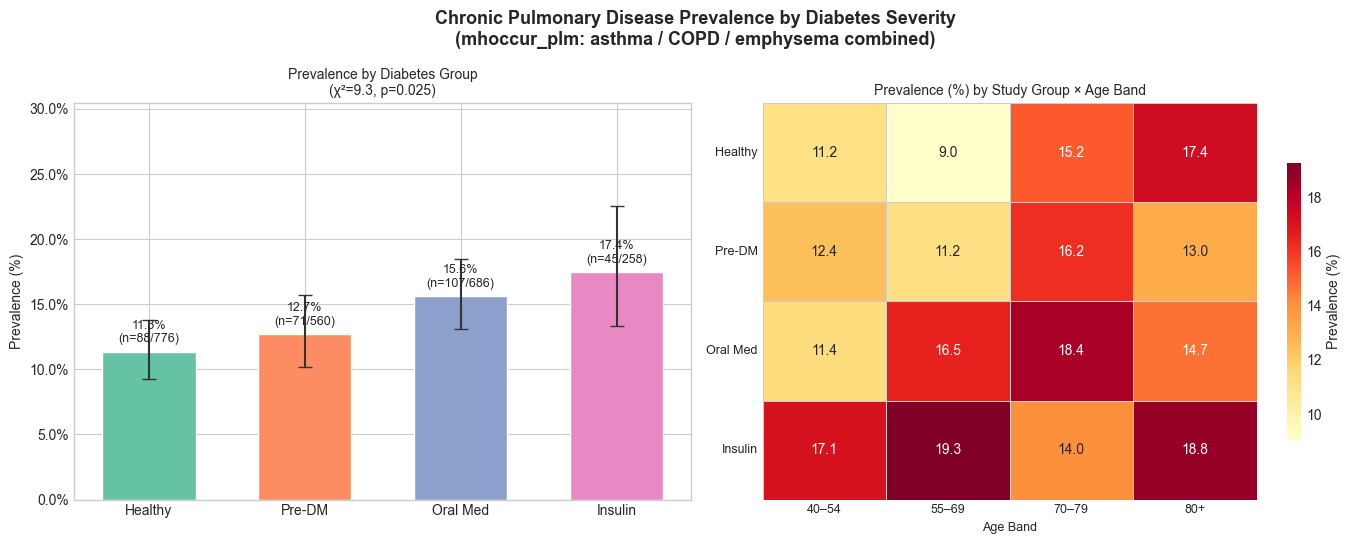


── Summary table ──
   group   n   k   pct  ci_lo  ci_hi
 Healthy 776  88 11.34   9.30  13.76
  Pre-DM 560  71 12.68  10.17  15.69
Oral Med 686 107 15.60  13.07  18.50
 Insulin 258  45 17.44  13.30  22.54


In [4]:
# ── Analysis 1: Pulmonary Prevalence by Study Group ────────────────

# Compute prevalence and 95% Wilson CI per group
def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0: return 0, 0
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return max(0, centre - margin) * 100, min(1, centre + margin) * 100

grp_stats = []
for grp in STUDY_GROUP_ORDER:
    sub = df[df['study_group_label'] == grp]
    n   = len(sub)
    k   = sub['pulmonary'].sum()
    pct = k / n * 100
    lo, hi = wilson_ci(k, n)
    grp_stats.append({'group': grp, 'n': n, 'k': int(k), 'pct': pct, 'ci_lo': lo, 'ci_hi': hi})

grp_df = pd.DataFrame(grp_stats)

# Chi-squared test across all 4 groups
ct = pd.crosstab(df['study_group_label'], df['pulmonary'])
chi2_stat, p_chi2, dof, _ = chi2_contingency(ct)
print(f'Chi-squared test (4 groups vs pulmonary): χ²={chi2_stat:.2f}, df={dof}, p={p_chi2:.4f}')

# Pairwise: Healthy vs each other group (Bonferroni × 3)
# Build 2×2 table from direct counts to avoid pd.crosstab index-alignment issues.
print('\nPairwise vs Healthy (Fisher exact, Bonferroni corrected):')
healthy_vec = df[df['study_group_label'] == 'Healthy']['pulmonary']
h_plm  = int((healthy_vec == 1).sum())
h_nplm = int((healthy_vec == 0).sum())
for grp in ['Pre-DM', 'Oral Med', 'Insulin']:
    other_vec = df[df['study_group_label'] == grp]['pulmonary']
    o_plm  = int((other_vec == 1).sum())
    o_nplm = int((other_vec == 0).sum())
    try:
        _, p_fe = fisher_exact([[h_plm, h_nplm], [o_plm, o_nplm]])
    except Exception:
        p_fe = 1.0
    p_adj = min(1.0, p_fe * 3)
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    print(f'  Healthy vs {grp:<10} p_raw={p_fe:.4f}  p_adj={p_adj:.4f}  {sig}')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Chronic Pulmonary Disease Prevalence by Diabetes Severity\n'
             '(mhoccur_plm: asthma / COPD / emphysema combined)',
             fontsize=13, fontweight='bold')

# Panel A: bar chart with CI
ax = axes[0]
colors = GROUP_COLORS
bars = ax.bar(grp_df['group'], grp_df['pct'], color=colors, edgecolor='white', width=0.6)
ax.errorbar(grp_df['group'], grp_df['pct'],
            yerr=[grp_df['pct'] - grp_df['ci_lo'], grp_df['ci_hi'] - grp_df['pct']],
            fmt='none', color='#333333', capsize=5, linewidth=1.5)
for bar, row in zip(bars, grp_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row.pct:.1f}%\n(n={row.k}/{row.n})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Prevalence (%)', fontsize=10)
ax.set_title(f'Prevalence by Diabetes Group\n(χ²={chi2_stat:.1f}, p={p_chi2:.3f})', fontsize=10)
ax.set_ylim(0, grp_df['ci_hi'].max() * 1.35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Panel B: age-stratified heatmap
ax = axes[1]
age_grp_prev = []
for sg in STUDY_GROUP_ORDER:
    for ag in AGE_ORDER:
        sub = df[(df['study_group_label'] == sg) & (df['age_group'] == ag)]
        n   = len(sub)
        pct = sub['pulmonary'].mean() * 100 if n >= 5 else np.nan
        age_grp_prev.append({'study_group': sg, 'age_group': ag, 'pct': pct, 'n': n})

heat_prev = (pd.DataFrame(age_grp_prev)
             .pivot_table(index='study_group', columns='age_group',
                          values='pct', aggfunc='first')
             .reindex(index=STUDY_GROUP_ORDER, columns=AGE_ORDER))

sns.heatmap(heat_prev, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#cccccc',
            annot_kws={'size': 10}, ax=ax,
            cbar_kws={'label': 'Prevalence (%)', 'shrink': 0.7})
ax.set_title('Prevalence (%) by Study Group × Age Band', fontsize=10)
ax.set_xlabel('Age Band', fontsize=9)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

print('\n── Summary table ──')
print(grp_df.to_string(index=False))

---
## 5. Analysis 2 — Comorbidity Enrichment in Pulmonary Patients

> **Question**: Which conditions co-occur significantly more in patients with chronic pulmonary disease?
>
> **Literature anchor**: Obesity is the strongest shared risk factor (asthma + T2DM). Cardiovascular
> disease, hypertension, and depression are also enriched in asthma cohorts.
> Fisher's exact test applied to each of the 28 other mhoccur flags; FDR-corrected (Benjamini-Hochberg).

=== Top comorbidities enriched in pulmonary patients (FDR < 0.05) ===
                                label  prev_pulmonary  prev_non_pulm  diff  odds_ratio  p_fdr
Digestive problems (Examples: stomach           40.50          20.40 20.10        2.66   0.00
  Mild cognitive impairment (known as            7.70           3.10  4.60        2.62   0.00
               Arthritis (joint pain)           60.80          38.80 22.00        2.45   0.00
                              Obesity           56.90          35.70 21.30        2.38   0.00
                               Stroke            9.00           4.30  4.70        2.19   0.00
        Other neurological conditions           14.80           7.90  6.90        2.02   0.00
                  High blood pressure           64.60          48.60 16.10        1.94   0.00
   Other heart issues (Examples: pace           22.20          12.90  9.30        1.93   0.00
  Have you fallen in the last 12 mont           25.40          15.40 10.00        1.

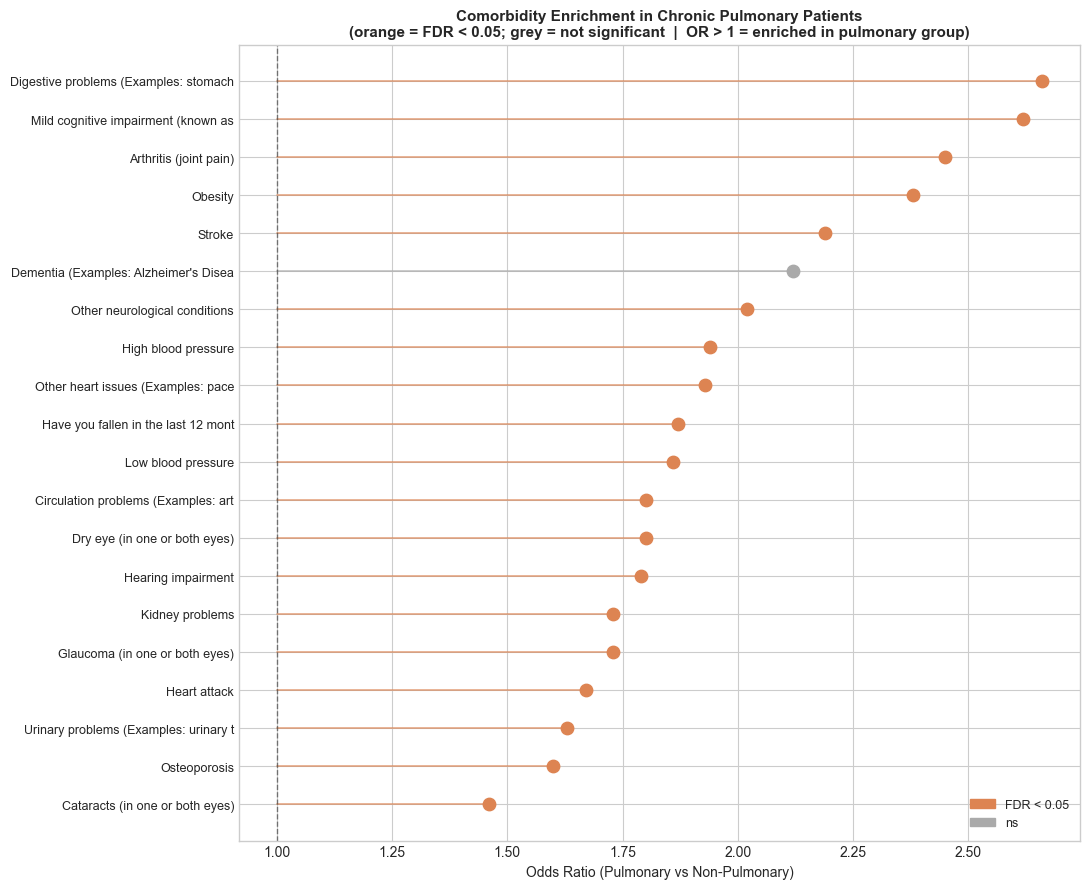

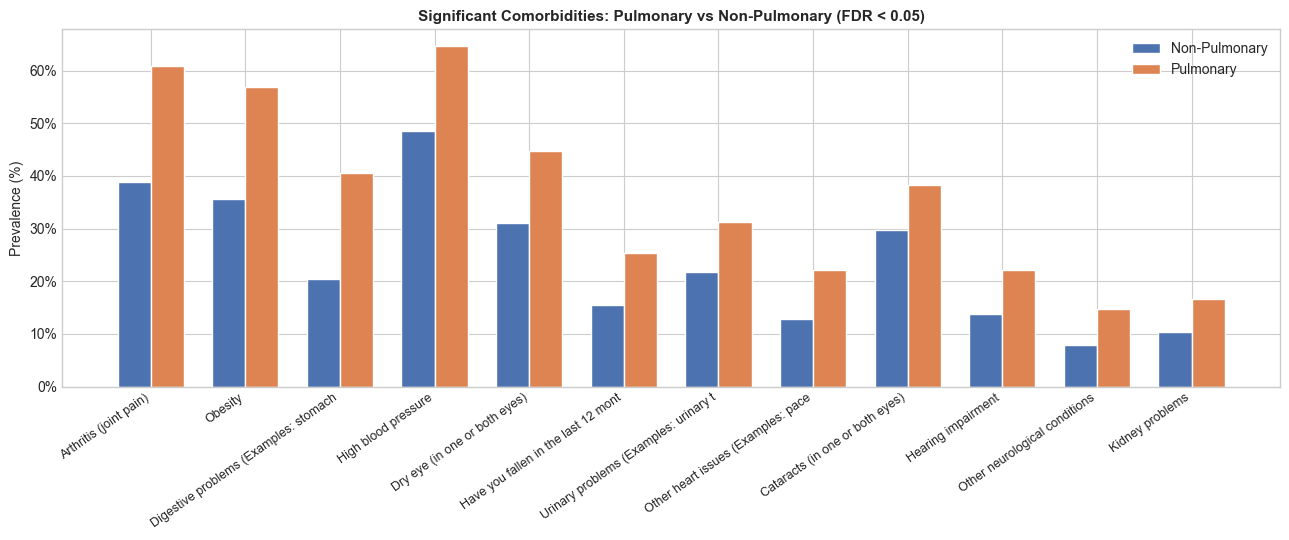

In [5]:
# ── Analysis 2: Comorbidity Enrichment ────────────────────────────

# Exclude the pulmonary flag itself and non-binary items
other_cols = [c for c in disease_cols if c != 'mhoccur_plm' and c != 'mhoccur_yn']

plm1 = df[df['pulmonary'] == 1]
plm0 = df[df['pulmonary'] == 0]

enrich_records = []
for col in other_cols:
    label = label_map.get(col, col)
    p1 = plm1[col].mean(skipna=True)
    p0 = plm0[col].mean(skipna=True)

    a = int(plm1[col].sum(skipna=True))
    b = int(plm1[col].count()) - a
    c = int(plm0[col].sum(skipna=True))
    d = int(plm0[col].count()) - c

    try:
        odds_r, p_fe = fisher_exact([[a, b], [c, d]])
    except Exception:
        odds_r, p_fe = np.nan, 1.0

    enrich_records.append({
        'col': col, 'label': label[:50],
        'prev_pulmonary': round(p1 * 100, 1),
        'prev_non_pulm':  round(p0 * 100, 1),
        'diff': round((p1 - p0) * 100, 1),
        'odds_ratio': round(odds_r, 2),
        'p_fisher': p_fe
    })

enrich_df = pd.DataFrame(enrich_records)

# FDR correction
_, enrich_df['p_fdr'], _, _ = multipletests(enrich_df['p_fisher'], method='fdr_bh')
enrich_df['significant'] = enrich_df['p_fdr'] < 0.05
enrich_df = enrich_df.sort_values('odds_ratio', ascending=False)

print('=== Top comorbidities enriched in pulmonary patients (FDR < 0.05) ===')
sig = enrich_df[enrich_df['significant']]
print(sig[['label', 'prev_pulmonary', 'prev_non_pulm', 'diff', 'odds_ratio', 'p_fdr']]
      .to_string(index=False))

# ── Plot: lollipop chart ──────────────────────────────────────────
plot_df = enrich_df.head(20).copy()
plot_df = plot_df.sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(11, 9))

for i, row in enumerate(plot_df.itertuples()):
    color = '#DD8452' if row.significant else '#aaaaaa'
    ax.plot([1, row.odds_ratio], [i, i], color=color, linewidth=1.2, alpha=0.7)
    ax.scatter(row.odds_ratio, i, color=color, s=80, zorder=5)

ax.axvline(1.0, color='#333333', linewidth=1.0, linestyle='--', alpha=0.6)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'].tolist(), fontsize=9)
ax.set_xlabel('Odds Ratio (Pulmonary vs Non-Pulmonary)', fontsize=10)
ax.set_title(
    'Comorbidity Enrichment in Chronic Pulmonary Patients\n'
    '(orange = FDR < 0.05; grey = not significant  |  OR > 1 = enriched in pulmonary group)',
    fontsize=11, fontweight='bold'
)

sig_patch   = mpatches.Patch(color='#DD8452', label='FDR < 0.05')
insig_patch = mpatches.Patch(color='#aaaaaa', label='ns')
ax.legend(handles=[sig_patch, insig_patch], fontsize=9)
plt.tight_layout()
plt.show()

# Side-by-side bar: pulmonary vs non-pulmonary prevalence for significant conditions
if len(sig) > 0:
    sig_plot = sig.sort_values('diff', ascending=False).head(12)
    x = np.arange(len(sig_plot))
    w = 0.35

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.bar(x - w/2, sig_plot['prev_non_pulm'], width=w,
           label='Non-Pulmonary', color='#4C72B0', edgecolor='white')
    ax.bar(x + w/2, sig_plot['prev_pulmonary'], width=w,
           label='Pulmonary', color='#DD8452', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(sig_plot['label'].tolist(), rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Prevalence (%)')
    ax.set_title('Significant Comorbidities: Pulmonary vs Non-Pulmonary (FDR < 0.05)',
                 fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

---
## 6. Analysis 3 — HbA1c by Pulmonary Status × Diabetes Group

> **Question**: Do pulmonary patients show worse glycemic control (higher HbA1c) within the same
> diabetes severity group?
>
> **Literature anchor**: High-dose inhaled corticosteroids (ICS) raise HbA1c by ~0.2–0.5%;
> oral corticosteroid bursts can spike glucose acutely. Steroid use is far more common in
> COPD/asthma patients. If this signal is present, it would manifest as higher HbA1c in the
> pulmonary group, especially at advanced diabetes stages.

HbA1c available: 2,211 patients

HbA1c coverage by group:
                   count  mean  median  std
study_group_label                          
Healthy              760  5.54    5.50 0.51
Pre-DM               546  5.85    5.80 0.53
Oral Med             657  6.55    6.30 1.10
Insulin              248  7.38    7.00 1.73

── Mann-Whitney U: Pulmonary vs Non-Pulmonary within each group ──
  Healthy   : Pulm median=5.50%  Non-Pulm median=5.50%  Δ=+0.00  p=0.6588
  Pre-DM    : Pulm median=5.70%  Non-Pulm median=5.80%  Δ=-0.10  p=0.2379
  Oral Med  : Pulm median=6.20%  Non-Pulm median=6.30%  Δ=-0.10  p=0.0141
  Insulin   : Pulm median=6.70%  Non-Pulm median=7.00%  Δ=-0.30  p=0.2785


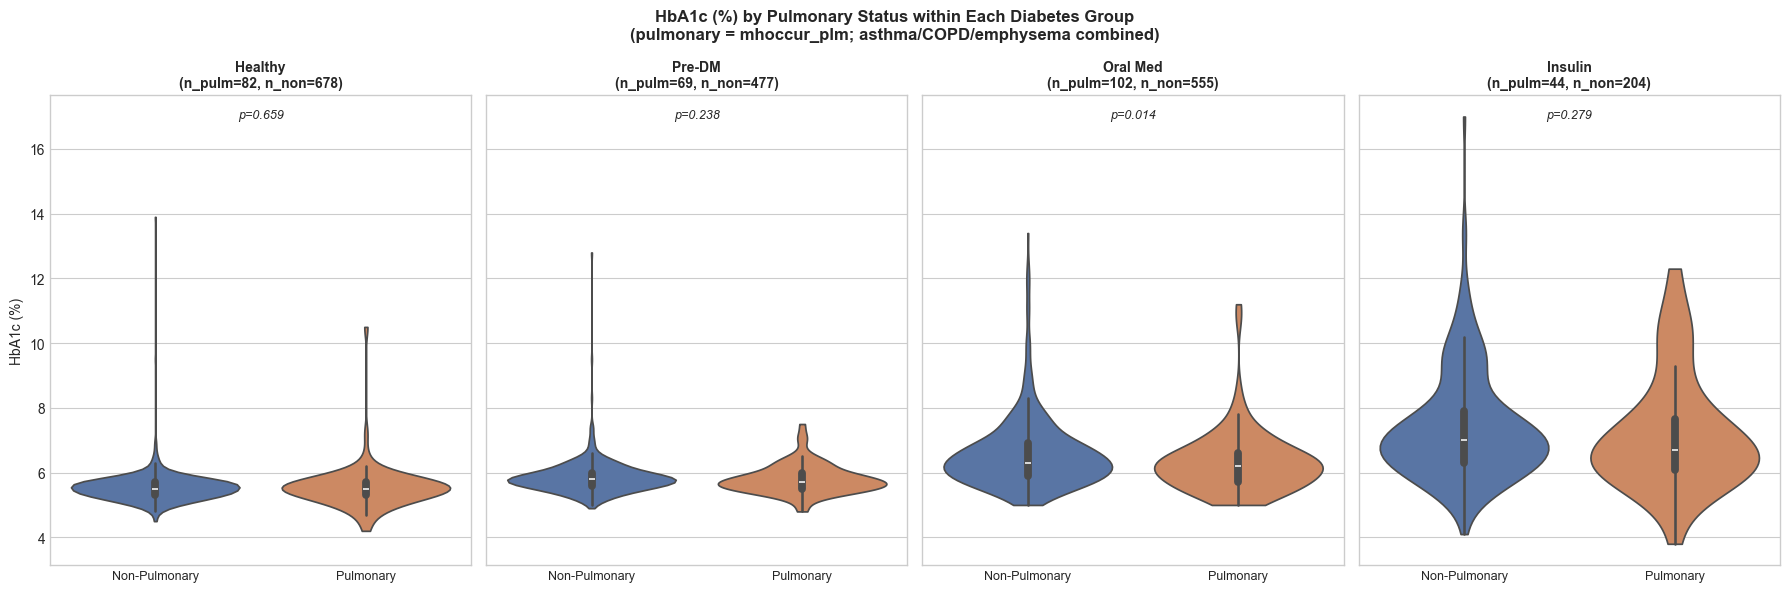


── OLS: HbA1c ~ pulmonary + study_group_code + age ──
                  Coef.  Std.Err.     t  P>|t|
Intercept          5.31      0.11 47.51   0.00
pulmonary         -0.13      0.06 -2.20   0.03
study_group_code   0.58      0.02 29.84   0.00
age                0.00      0.00  1.34   0.18


In [6]:
# ── Analysis 3: HbA1c by Pulmonary × Study Group ─────────────────

hba1c_df = df[df['hba1c'].notna()].copy()
n_hba1c  = len(hba1c_df)
print(f'HbA1c available: {n_hba1c:,} patients')
print('\nHbA1c coverage by group:')
print(hba1c_df.groupby('study_group_label', observed=True)['hba1c']
      .agg(['count', 'mean', 'median', 'std']).round(2).to_string())

# Mann-Whitney U per diabetes group
print('\n── Mann-Whitney U: Pulmonary vs Non-Pulmonary within each group ──')
mw_results = []
for grp in STUDY_GROUP_ORDER:
    sub  = hba1c_df[hba1c_df['study_group_label'] == grp]
    plm  = sub[sub['pulmonary'] == 1]['hba1c'].dropna()
    nplm = sub[sub['pulmonary'] == 0]['hba1c'].dropna()
    if len(plm) < 5 or len(nplm) < 5:
        mw_results.append({'group': grp, 'n_plm': len(plm), 'n_nplm': len(nplm),
                           'med_plm': np.nan, 'med_nplm': np.nan, 'p': np.nan})
        continue
    stat, p = mannwhitneyu(plm, nplm, alternative='two-sided')
    mw_results.append({
        'group': grp, 'n_plm': len(plm), 'n_nplm': len(nplm),
        'med_plm': round(plm.median(), 2), 'med_nplm': round(nplm.median(), 2),
        'diff': round(plm.median() - nplm.median(), 2),
        'p': round(p, 4)
    })
    print(f'  {grp:<10}: Pulm median={plm.median():.2f}%  Non-Pulm median={nplm.median():.2f}%  '
          f'Δ={plm.median()-nplm.median():+.2f}  p={p:.4f}')

mw_df = pd.DataFrame(mw_results)

# ── Plot: 2×4 violin grid ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
fig.suptitle('HbA1c (%) by Pulmonary Status within Each Diabetes Group\n'
             '(pulmonary = mhoccur_plm; asthma/COPD/emphysema combined)',
             fontsize=12, fontweight='bold')

for ax, grp, color in zip(axes, STUDY_GROUP_ORDER, GROUP_COLORS):
    sub = hba1c_df[hba1c_df['study_group_label'] == grp]
    if len(sub) < 10:
        ax.set_title(grp)
        ax.text(0.5, 0.5, 'Insufficient\ndata', ha='center', va='center',
                transform=ax.transAxes)
        continue

    sns.violinplot(data=sub, x='pulmonary_label', y='hba1c', order=PLM_ORDER,
                  palette=PLM_COLORS, inner='box', cut=0, ax=ax)

    # annotate p-value
    row = mw_df[mw_df['group'] == grp]
    if len(row) and pd.notna(row.iloc[0]['p']):
        p_val = row.iloc[0]['p']
        p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
        y_top = sub['hba1c'].quantile(0.95)
        ax.text(0.5, 0.97, p_str, ha='center', va='top',
                transform=ax.transAxes, fontsize=9, style='italic')

    n_plm  = len(sub[sub['pulmonary'] == 1])
    n_nplm = len(sub[sub['pulmonary'] == 0])
    ax.set_title(f'{grp}\n(n_pulm={n_plm}, n_non={n_nplm})', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('HbA1c (%)' if ax is axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

# Regression: HbA1c ~ pulmonary + study_group + age (partial-out confounders)
try:
    from statsmodels.formula.api import ols
    reg_df = hba1c_df.dropna(subset=['hba1c', 'age', 'study_group_code']).copy()
    model = ols('hba1c ~ pulmonary + study_group_code + age', data=reg_df).fit()
    print('\n── OLS: HbA1c ~ pulmonary + study_group_code + age ──')
    print(model.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']].round(3).to_string())
except Exception as e:
    print(f'Regression skipped: {e}')

---
## 7. Analysis 4 — CGM Metrics by Pulmonary Status

> **Question**: Do pulmonary patients show worse real-time glycemic control (CGM-derived metrics)
> compared to non-pulmonary patients within the same diabetes stage?
>
> **Literature anchor**: Corticosteroid-induced glucose spikes increase glucose variability (CV%)
> and reduce Time in Range (TIR) acutely. If these patients are on chronic ICS/OCS therapy,
> we'd expect elevated CV% and lower TIR in the pulmonary group.

CGM data available: 2,245 patients
Coverage: 98.5% of cohort

── CGM Metrics: Pulmonary vs Non-Pulmonary (Mann-Whitney U) ──

  Mean Glucose (mg/dL):
    Healthy   : Pulm=114.3  Non-Pulm=116.4  Δ=-2.1  p=0.3231
    Pre-DM    : Pulm=122.7  Non-Pulm=122.2  Δ=+0.5  p=0.4982
    Oral Med  : Pulm=135.9  Non-Pulm=140.1  Δ=-4.2  p=0.3600
    Insulin   : Pulm=158.2  Non-Pulm=169.6  Δ=-11.4  p=0.2249

  Time in Range (70–180 mg/dL) (%):
    Healthy   : Pulm=98.1  Non-Pulm=98.4  Δ=-0.2  p=0.8630
    Pre-DM    : Pulm=97.0  Non-Pulm=97.5  Δ=-0.5  p=0.8505
    Oral Med  : Pulm=91.3  Non-Pulm=89.0  Δ=+2.3  p=0.3730
    Insulin   : Pulm=70.4  Non-Pulm=62.5  Δ=+8.0  p=0.1841

  Glucose CV (%):
    Healthy   : Pulm=17.2  Non-Pulm=16.7  Δ=+0.5  p=0.6339
    Pre-DM    : Pulm=17.9  Non-Pulm=17.7  Δ=+0.2  p=0.3680
    Oral Med  : Pulm=19.9  Non-Pulm=20.4  Δ=-0.5  p=0.7764
    Insulin   : Pulm=25.8  Non-Pulm=25.3  Δ=+0.5  p=0.9161

  Glucose Management Indicator (%):
    Healthy   : Pulm=6.0  Non-Pulm=6.1  

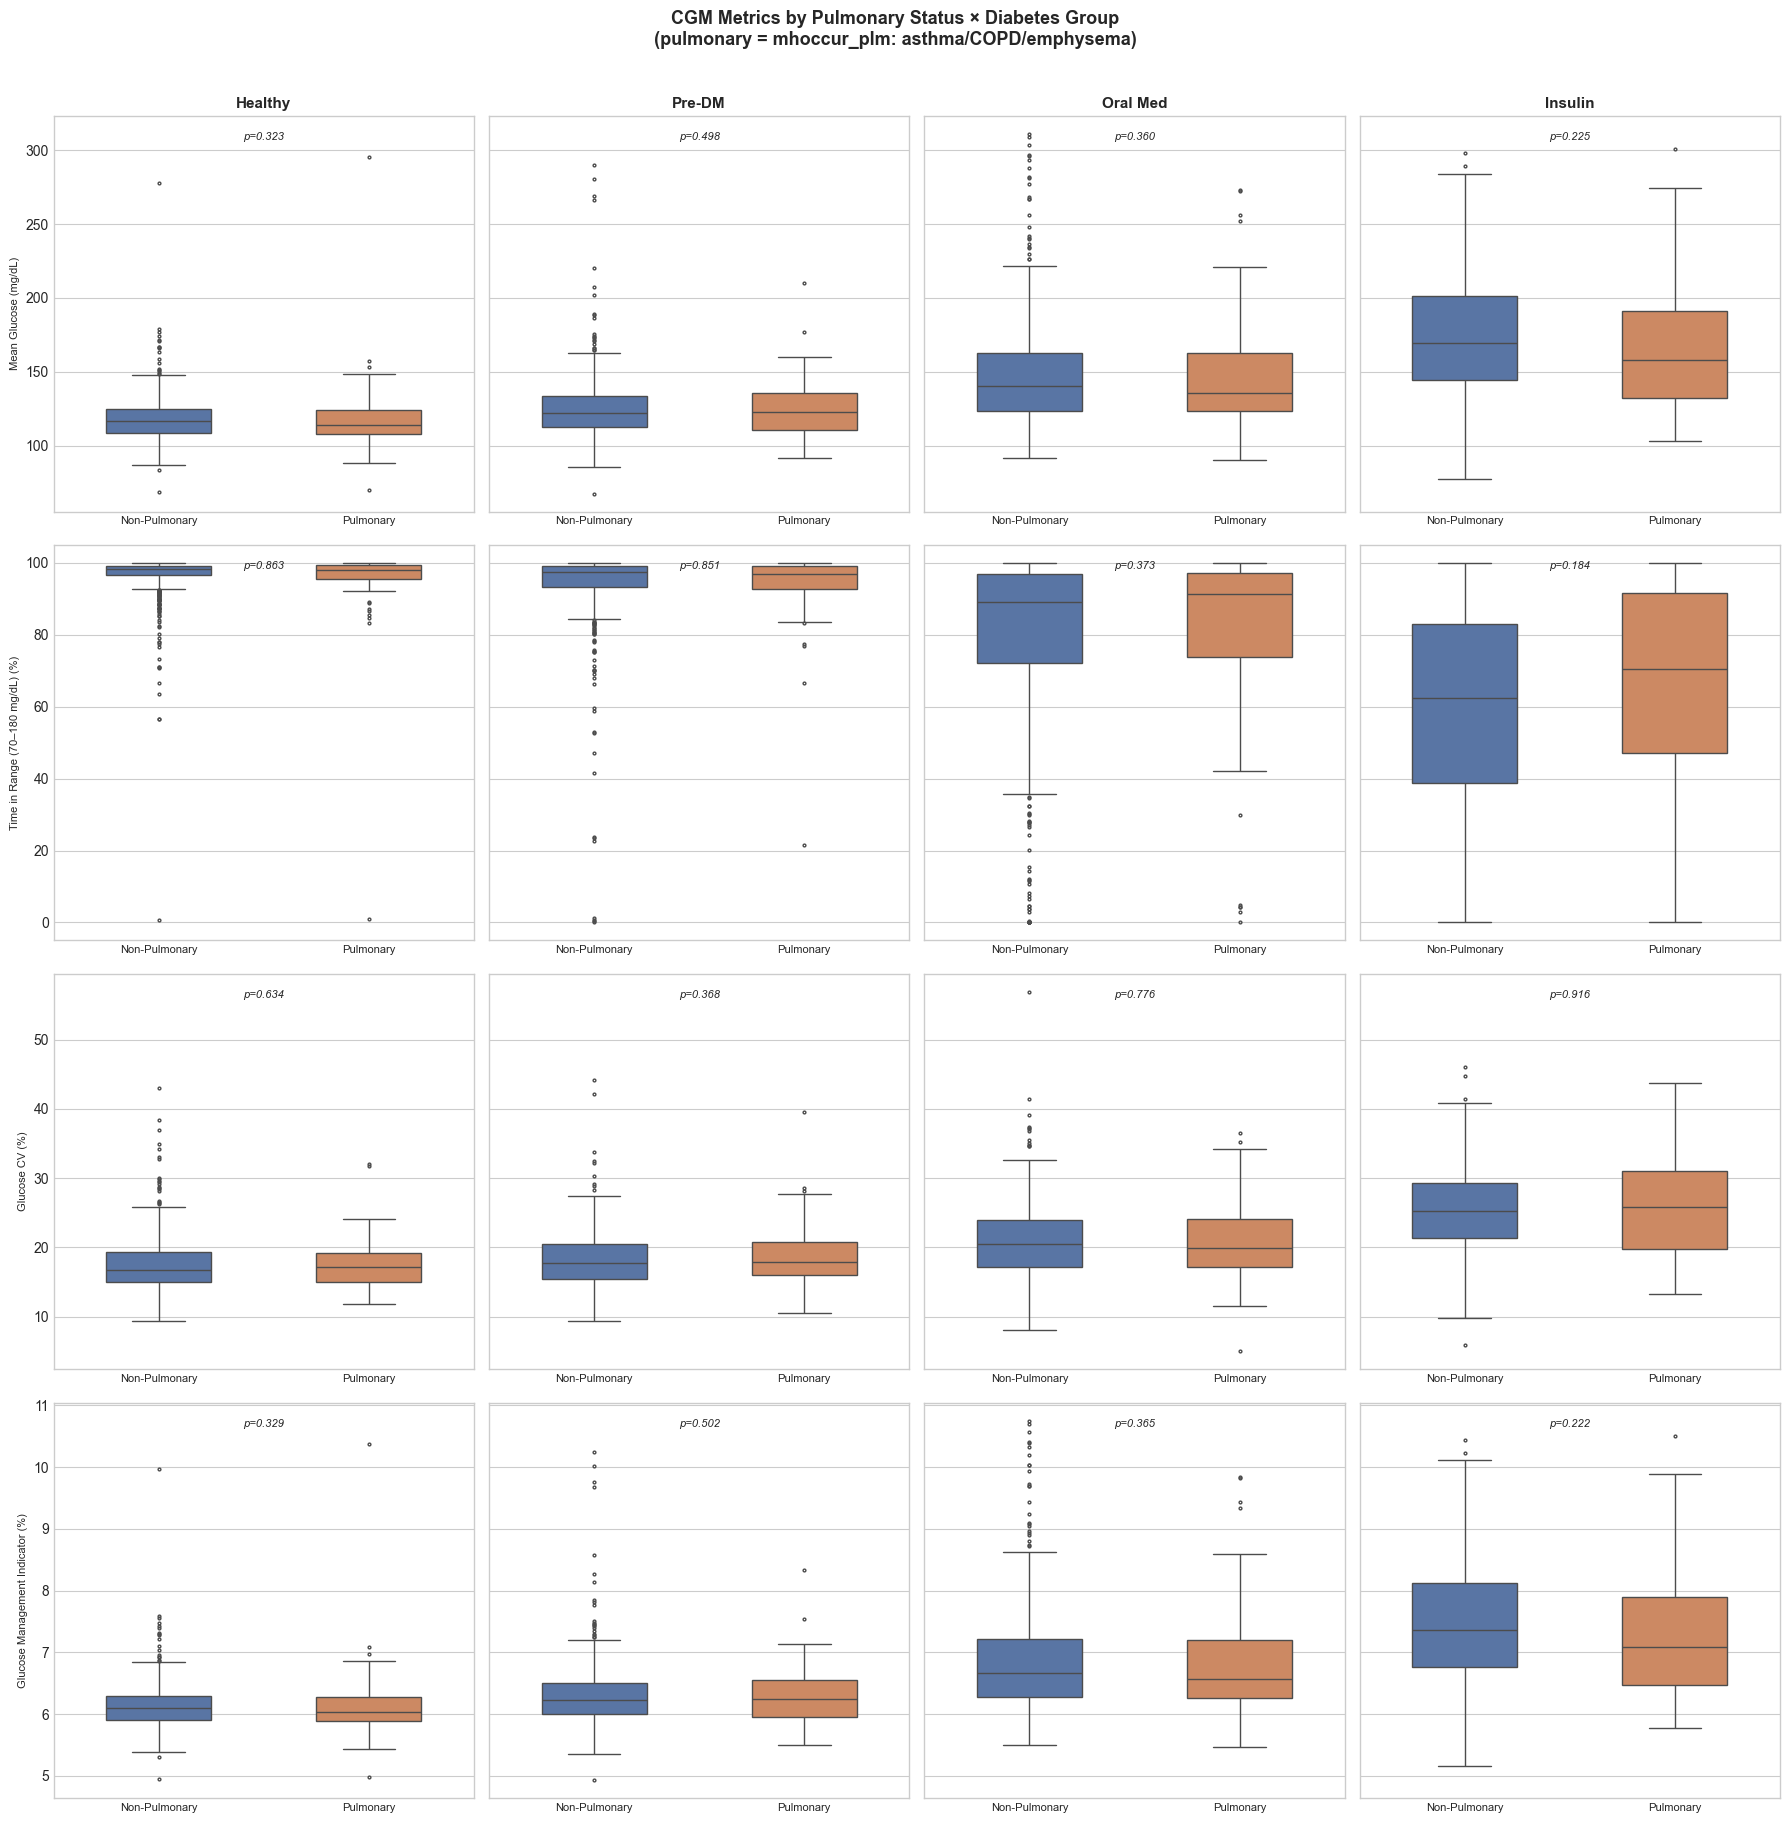

In [7]:
# ── Analysis 4: CGM Metrics by Pulmonary Status ────────────────────

cgm_df = df[df['mean_glucose'].notna()].copy()
print(f'CGM data available: {len(cgm_df):,} patients')
print(f'Coverage: {len(cgm_df)/len(df)*100:.1f}% of cohort')

cgm_metrics_list = [
    ('mean_glucose', 'Mean Glucose (mg/dL)'),
    ('tir',          'Time in Range (70–180 mg/dL) (%)'),
    ('cv_glucose',   'Glucose CV (%)'),
    ('gmi',          'Glucose Management Indicator (%)'),
]

# ── Mann-Whitney for each metric × group ─────────────────────────
print('\n── CGM Metrics: Pulmonary vs Non-Pulmonary (Mann-Whitney U) ──')
for metric, label in cgm_metrics_list:
    if metric not in cgm_df.columns:
        print(f'  {label}: not available')
        continue
    print(f'\n  {label}:')
    for grp in STUDY_GROUP_ORDER:
        sub  = cgm_df[cgm_df['study_group_label'] == grp]
        plm  = sub[sub['pulmonary'] == 1][metric].dropna()
        nplm = sub[sub['pulmonary'] == 0][metric].dropna()
        if len(plm) < 5 or len(nplm) < 5:
            print(f'    {grp:<10}: insufficient data (n_plm={len(plm)}, n_nplm={len(nplm)})')
            continue
        _, p = mannwhitneyu(plm, nplm, alternative='two-sided')
        print(f'    {grp:<10}: Pulm={plm.median():.1f}  Non-Pulm={nplm.median():.1f}  '
              f'Δ={plm.median()-nplm.median():+.1f}  p={p:.4f}')

# ── 2×4 facet: metric × study group ──────────────────────────────
available_metrics = [(m, l) for m, l in cgm_metrics_list if m in cgm_df.columns]
n_metrics = len(available_metrics)

if n_metrics > 0 and len(cgm_df) > 20:
    fig, axes = plt.subplots(n_metrics, 4, figsize=(18, 4.5 * n_metrics),
                             sharex=False, sharey='row')
    if n_metrics == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('CGM Metrics by Pulmonary Status × Diabetes Group\n'
                 '(pulmonary = mhoccur_plm: asthma/COPD/emphysema)',
                 fontsize=13, fontweight='bold', y=1.01)

    for row_i, (metric, label) in enumerate(available_metrics):
        for col_i, grp in enumerate(STUDY_GROUP_ORDER):
            ax  = axes[row_i, col_i]
            sub = cgm_df[cgm_df['study_group_label'] == grp]

            if sub[metric].notna().sum() < 10:
                ax.set_visible(False)
                continue

            sns.boxplot(data=sub, x='pulmonary_label', y=metric, order=PLM_ORDER,
                        palette=PLM_COLORS, width=0.5, fliersize=2, ax=ax)

            # p-value annotation
            plm_v  = sub[sub['pulmonary'] == 1][metric].dropna()
            nplm_v = sub[sub['pulmonary'] == 0][metric].dropna()
            if len(plm_v) >= 5 and len(nplm_v) >= 5:
                _, p = mannwhitneyu(plm_v, nplm_v, alternative='two-sided')
                p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
                ax.text(0.5, 0.96, p_str, ha='center', va='top',
                        transform=ax.transAxes, fontsize=8, style='italic')

            if row_i == 0:
                ax.set_title(grp, fontsize=11, fontweight='bold')
            ax.set_ylabel(label if col_i == 0 else '', fontsize=8)
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('Insufficient CGM data for faceted plots.')

---
## 8. Analysis 5 — Age-Stratified HbA1c Patterns

> **Question**: Does the pulmonary penalty on HbA1c vary by age?
>
> In younger patients (40–54), the `mhoccur_plm` group likely skews toward asthma.
> In older patients (70+), it likely skews toward COPD. Comparing the pulmonary–HbA1c
> relationship across age bands can partially distinguish these disease subtypes.

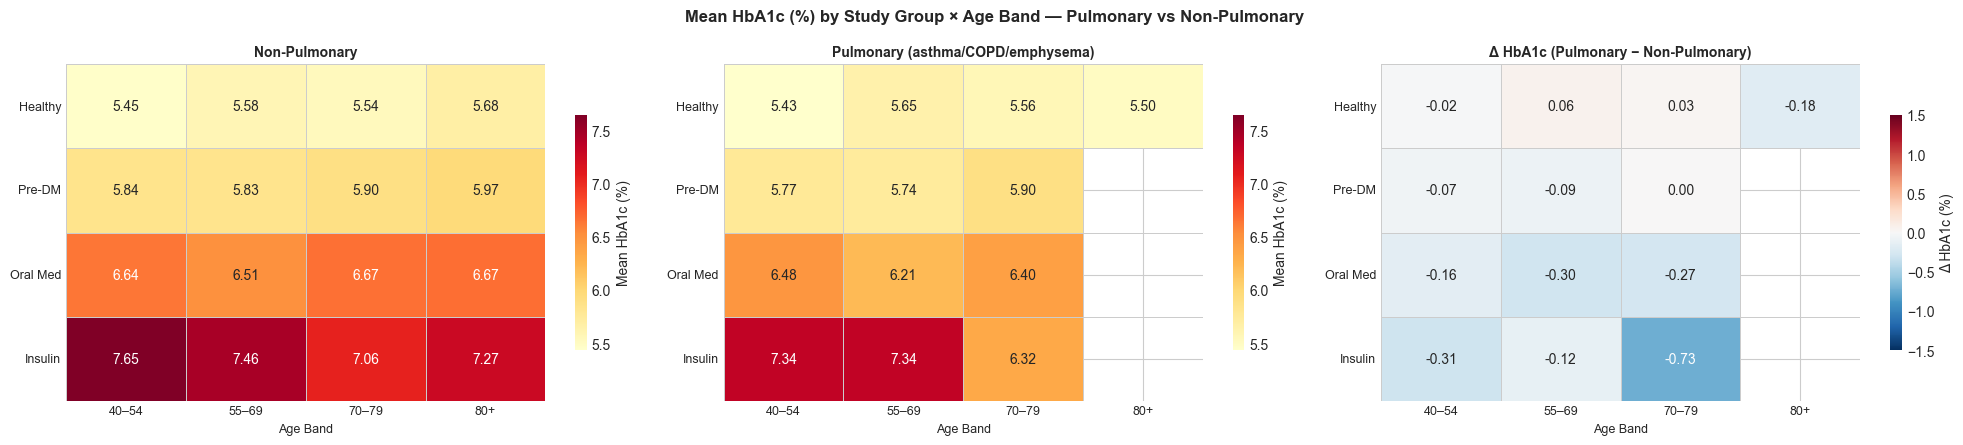


── Δ HbA1c table (Pulmonary − Non-Pulmonary) ──
Positive = pulmonary patients have higher HbA1c
age_group    40–54  55–69  70–79   80+
study_group                           
Healthy      -0.02   0.06   0.03 -0.18
Pre-DM       -0.07  -0.09   0.00   NaN
Oral Med     -0.16  -0.30  -0.27   NaN
Insulin      -0.31  -0.12  -0.73   NaN


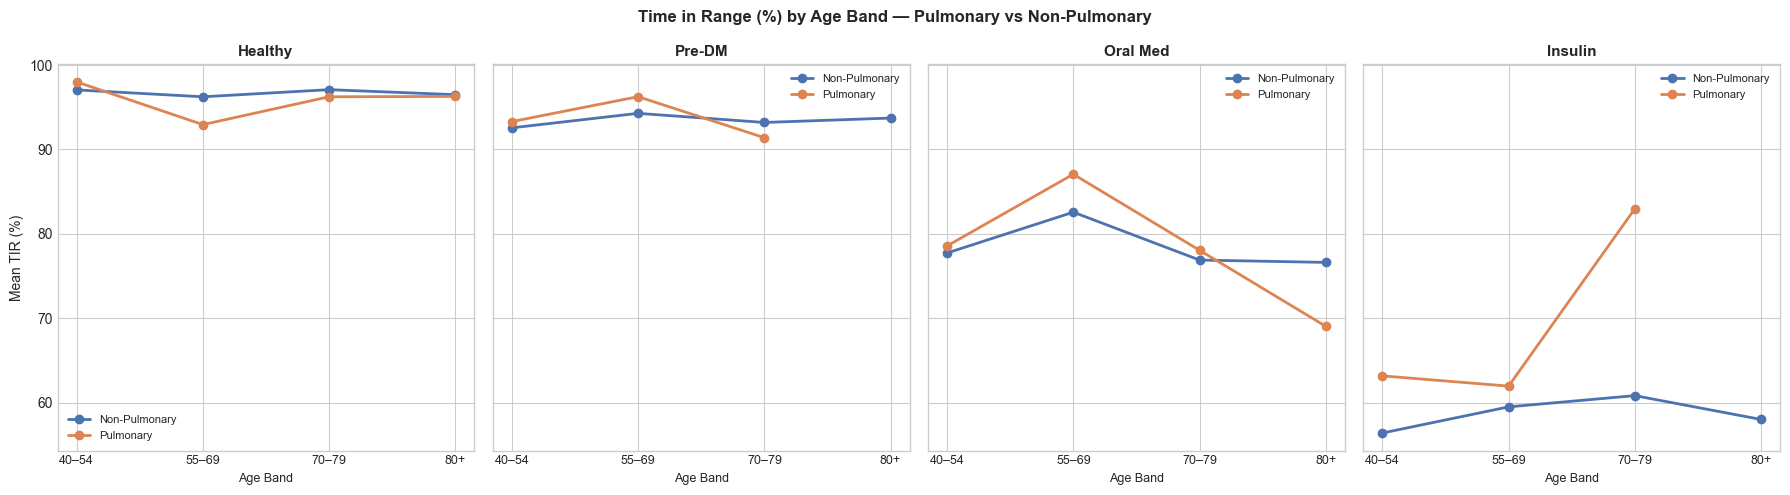

In [8]:
# ── Analysis 5: Age-Stratified HbA1c ─────────────────────────────

hba1c_df = df[df['hba1c'].notna()].copy()

# ── Panel A: Mean HbA1c heatmap (pulmonary) ──────────────────────
def build_hba1c_heat(data):
    """Build mean HbA1c pivot: study_group × age_group, suppress n<5."""
    records = []
    for sg in STUDY_GROUP_ORDER:
        for ag in AGE_ORDER:
            sub = data[(data['study_group_label'] == sg) & (data['age_group'] == ag)]
            n   = len(sub)
            val = sub['hba1c'].mean() if n >= 5 else np.nan
            records.append({'study_group': sg, 'age_group': ag, 'mean_hba1c': val, 'n': n})
    return (pd.DataFrame(records)
            .pivot_table(index='study_group', columns='age_group',
                         values='mean_hba1c', aggfunc='first')
            .reindex(index=STUDY_GROUP_ORDER, columns=AGE_ORDER))

heat_plm  = build_hba1c_heat(hba1c_df[hba1c_df['pulmonary'] == 1])
heat_nplm = build_hba1c_heat(hba1c_df[hba1c_df['pulmonary'] == 0])
heat_diff = (heat_plm - heat_nplm).round(2)  # Δ HbA1c: pulmonary minus non-pulmonary

fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
fig.suptitle('Mean HbA1c (%) by Study Group × Age Band — Pulmonary vs Non-Pulmonary',
             fontsize=12, fontweight='bold')

vmin = min(heat_plm.min().min(), heat_nplm.min().min())
vmax = max(heat_plm.max().max(), heat_nplm.max().max())

for ax, data, title in zip(axes,
                            [heat_nplm, heat_plm, heat_diff],
                            ['Non-Pulmonary', 'Pulmonary (asthma/COPD/emphysema)',
                             'Δ HbA1c (Pulmonary − Non-Pulmonary)']):
    if 'Δ' in title:
        cmap, vmin_p, vmax_p = 'RdBu_r', -1.5, 1.5
    else:
        cmap, vmin_p, vmax_p = 'YlOrRd', vmin, vmax

    sns.heatmap(data, annot=True, fmt='.2f', cmap=cmap,
                linewidths=0.5, linecolor='#cccccc',
                annot_kws={'size': 10}, ax=ax,
                vmin=vmin_p, vmax=vmax_p,
                cbar_kws={'label': 'Mean HbA1c (%)' if 'Δ' not in title else 'Δ HbA1c (%)',
                          'shrink': 0.7})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Age Band', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

print('\n── Δ HbA1c table (Pulmonary − Non-Pulmonary) ──')
print('Positive = pulmonary patients have higher HbA1c')
print(heat_diff.round(2).to_string())

# ── Panel B: TIR by age for pulmonary vs non-pulmonary ───────────
if 'tir' in df.columns and df['tir'].notna().sum() > 20:
    cgm_age = df[df['tir'].notna()].copy()
    tir_records = []
    for ag in AGE_ORDER:
        for sg in STUDY_GROUP_ORDER:
            for plm_val, plm_lbl in [(1, 'Pulmonary'), (0, 'Non-Pulmonary')]:
                sub = cgm_age[(cgm_age['age_group'] == ag) &
                              (cgm_age['study_group_label'] == sg) &
                              (cgm_age['pulmonary'] == plm_val)]
                if len(sub) >= 5:
                    tir_records.append({'age_group': ag, 'study_group': sg,
                                        'pulmonary_label': plm_lbl,
                                        'mean_tir': sub['tir'].mean(), 'n': len(sub)})

    tir_df = pd.DataFrame(tir_records)
    if len(tir_df) > 0:
        fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
        fig.suptitle('Time in Range (%) by Age Band — Pulmonary vs Non-Pulmonary',
                     fontsize=12, fontweight='bold')
        for ax, sg in zip(axes, STUDY_GROUP_ORDER):
            sub = tir_df[tir_df['study_group'] == sg]
            for plm_lbl, color in PLM_COLORS.items():
                sub2 = sub[sub['pulmonary_label'] == plm_lbl]
                if len(sub2) > 0:
                    ax.plot(sub2['age_group'], sub2['mean_tir'],
                            marker='o', color=color, label=plm_lbl, linewidth=2)
            ax.set_title(sg, fontsize=11, fontweight='bold')
            ax.set_xlabel('Age Band', fontsize=9)
            ax.set_ylabel('Mean TIR (%)' if ax is axes[0] else '')
            ax.legend(fontsize=8)
            ax.tick_params(axis='x', labelsize=9)
        plt.tight_layout()
        plt.show()

---
## 9. Analysis 6 — SDoH / Psychosocial Burden

> **Question**: Do patients with both chronic pulmonary disease and diabetes face a compounded
> social disadvantage — higher depression burden, weaker social support, or food insecurity?
>
> **Literature anchor**: Asthma has a well-documented bidirectional association with depression
> (OR ~1.8). In diabetes, psychosocial burden is a key driver of non-adherence. The intersection
> of both conditions may create an especially vulnerable group.

Found 4 SDoH scale(s):
  cesd_total: n=2,279, mean=11.70, median=10.0
  discrim_stress: n=2,280, mean=659.80, median=70.0
  food_insecurity: n=2,280, mean=51.02, median=0.0
  housing_score: n=2,063, mean=400.60, median=11.0

── Kruskal-Wallis: SDoH by pulmonary × Healthy vs Insulin ──

  CES-D-10 Depression Score (higher = worse, ≥10 = clinical flag):
    Healthy / No Pulm     : n=688  median=8.0  mean=10.2
    Healthy / Pulm        : n= 88  median=11.0  mean=12.6
    Insulin / No Pulm     : n=213  median=12.0  mean=14.2
    Insulin / Pulm        : n= 44  median=17.0  mean=18.9
    Kruskal-Wallis: H=41.57, p=0.0000

  Perceived Discrimination Stress Score (sum of pxrd* items):
    Healthy / No Pulm     : n=688  median=63.0  mean=674.0
    Healthy / Pulm        : n= 88  median=59.5  mean=687.2
    Insulin / No Pulm     : n=213  median=73.0  mean=664.4
    Insulin / Pulm        : n= 45  median=102.0  mean=500.0
    Kruskal-Wallis: H=14.07, p=0.0028

  Food Insecurity Score (sum of pxfi* 

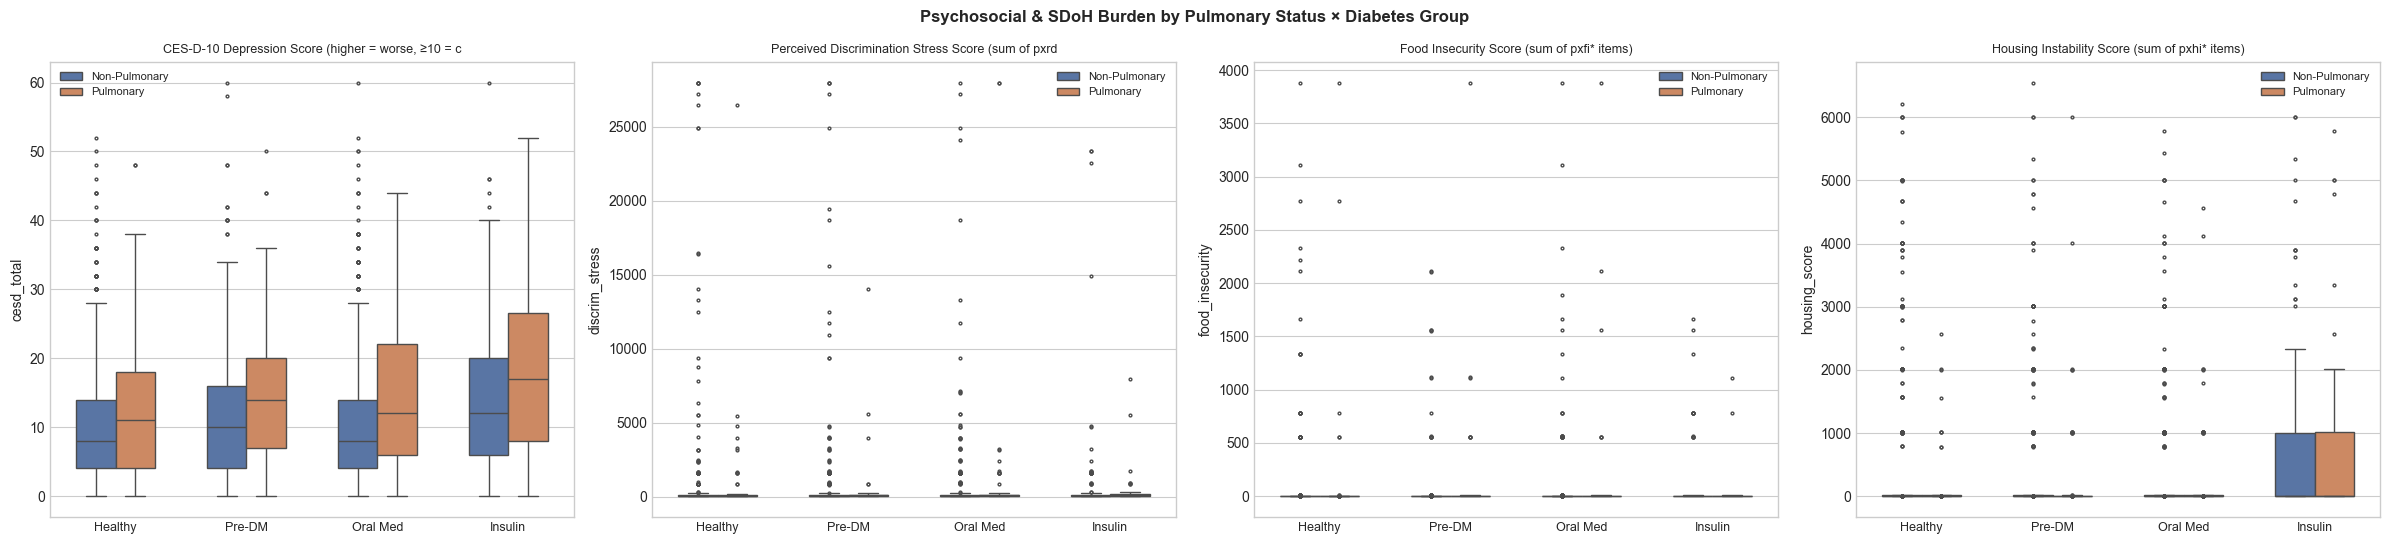

In [9]:
# ── Analysis 6: SDoH / Psychosocial Burden ───────────────────────

sdoh_scales = [
    ('cesd_total',     'CES-D-10 Depression Score (higher = worse, ≥10 = clinical flag)'),
    ('discrim_stress', 'Perceived Discrimination Stress Score (sum of pxrd* items)'),
    ('food_insecurity','Food Insecurity Score (sum of pxfi* items)'),
    ('housing_score',  'Housing Instability Score (sum of pxhi* items)'),
]

available_sdoh = [(col, label) for col, label in sdoh_scales
                  if col in df.columns and df[col].notna().sum() > 20]

if not available_sdoh:
    print('SDoH scales not found in df columns.')
    print('Columns present:', [c for c in df.columns if any(x in c for x in ['ces','pxrd','food','hous','discrim'])])
else:
    print(f'Found {len(available_sdoh)} SDoH scale(s):')
    for col, label in available_sdoh:
        n = df[col].notna().sum()
        print(f'  {col}: n={n:,}, mean={df[col].mean():.2f}, median={df[col].median():.1f}')

    # Kruskal-Wallis across 4 groups of interest:
    # Healthy-noPulm / Healthy-Pulm / Insulin-noPulm / Insulin-Pulm
    print('\n── Kruskal-Wallis: SDoH by pulmonary × Healthy vs Insulin ──')
    groups_of_interest = [
        ('Healthy', 0, 'Healthy / No Pulm'),
        ('Healthy', 1, 'Healthy / Pulm'),
        ('Insulin', 0, 'Insulin / No Pulm'),
        ('Insulin', 1, 'Insulin / Pulm'),
    ]
    for col, label in available_sdoh:
        print(f'\n  {label}:')
        vectors = []
        for sg, plm, name in groups_of_interest:
            v = df[(df['study_group_label'] == sg) &
                   (df['pulmonary'] == plm)][col].dropna()
            vectors.append(v)
            print(f'    {name:<22}: n={len(v):3d}  median={v.median():.1f}  mean={v.mean():.1f}')
        vecs_valid = [v for v in vectors if len(v) >= 5]
        if len(vecs_valid) >= 2:
            stat, p = kruskal(*vecs_valid)
            print(f'    Kruskal-Wallis: H={stat:.2f}, p={p:.4f}')

    # ── Mann-Whitney: pulmonary vs non-pulmonary within each group ──
    print('\n── Mann-Whitney U: Pulmonary vs Non-Pulmonary per diabetes group ──')
    for col, label in available_sdoh:
        print(f'\n  {label}:')
        for grp in STUDY_GROUP_ORDER:
            sub  = df[df['study_group_label'] == grp]
            plm  = sub[sub['pulmonary'] == 1][col].dropna()
            nplm = sub[sub['pulmonary'] == 0][col].dropna()
            if len(plm) < 5 or len(nplm) < 5:
                continue
            _, p = mannwhitneyu(plm, nplm, alternative='two-sided')
            print(f'    {grp:<10}: Pulm={plm.median():.1f}  Non-Pulm={nplm.median():.1f}  Δ={plm.median()-nplm.median():+.1f}  p={p:.4f}')

    # ── Plot: grouped boxplots ─────────────────────────────────────
    n_scales = len(available_sdoh)
    fig, axes = plt.subplots(1, n_scales, figsize=(6 * n_scales, 5.5))
    if n_scales == 1:
        axes = [axes]
    fig.suptitle('Psychosocial & SDoH Burden by Pulmonary Status × Diabetes Group',
                 fontsize=12, fontweight='bold')

    for ax, (col, label) in zip(axes, available_sdoh):
        plot_data = df[df[col].notna() & df['study_group_label'].notna() &
                       df['pulmonary_label'].notna()].copy()
        sns.boxplot(data=plot_data, x='study_group_label', y=col,
                    hue='pulmonary_label', hue_order=PLM_ORDER,
                    palette=PLM_COLORS, width=0.6, fliersize=2, ax=ax)
        ax.set_title(label[:50], fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel(col)
        ax.tick_params(axis='x', labelsize=9)
        ax.legend(title='', fontsize=8)

    plt.tight_layout()
    plt.show()

---
## Key Findings

---

### Analysis 1 — Pulmonary Prevalence by Diabetes Severity

- **13.6% of the AI-READI cohort** (311 / 2,280) reports chronic pulmonary disease (`mhoccur_plm`; asthma / COPD / emphysema combined).
- Prevalence rises across diabetes severity: **11.3%** (Healthy) → **12.7%** (Pre-DM) → **15.6%** (Oral Med) → **17.4%** (Insulin).
- Overall chi-squared test: **χ²=9.32, p=0.025** — the trend is statistically significant.
- Pairwise vs Healthy (Bonferroni corrected): **Insulin p=0.041\*** (significant); Oral Med p=0.062 (borderline); Pre-DM p=1.0 (ns).
- The gradient is present but modest — pulmonary disease prevalence does not show the dramatic stepwise escalation seen for hypertension or obesity in NB27.

---

### Analysis 2 — Comorbidity Enrichment in Pulmonary Patients

**19 of 27 conditions** are significantly enriched in pulmonary patients (Fisher exact, FDR < 0.05).

| Condition | Pulmonary % | Non-Pulmonary % | Δ | Odds Ratio |
|---|---|---|---|---|
| Digestive problems | 40.5% | 20.4% | +20.1pp | **2.66** |
| Mild cognitive impairment | 7.7% | 3.1% | +4.6pp | **2.62** |
| Arthritis (joint pain) | 60.8% | 38.8% | +22.0pp | **2.45** |
| Obesity | 56.9% | 35.7% | +21.3pp | **2.38** |
| Stroke | 9.0% | 4.3% | +4.7pp | **2.19** |
| Other neurological conditions | 14.8% | 7.9% | +6.9pp | **2.02** |
| High blood pressure | 64.6% | 48.6% | +16.1pp | **1.94** |
| Other heart issues | 22.2% | 12.9% | +9.3pp | **1.93** |
| Falls (last 12 months) | 25.4% | 15.4% | +10.0pp | **1.87** |
| Low blood pressure | 9.3% | 5.2% | +4.1pp | **1.86** |
| Circulation problems | 14.1% | 8.4% | +5.8pp | **1.80** |
| Dry eye | 44.7% | 31.0% | +13.7pp | **1.80** |
| Hearing impairment | 22.2% | 13.8% | +8.4pp | **1.79** |
| Kidney problems | 16.7% | 10.4% | +6.3pp | **1.73** |
| Glaucoma | 13.8% | 8.5% | +5.3pp | **1.73** |
| Urinary problems | 31.2% | 21.8% | +9.4pp | **1.63** |
| Osteoporosis | 18.6% | 12.5% | +6.1pp | **1.60** |
| Cataracts | 38.3% | 29.8% | +8.5pp | **1.46** |
| Heart attack | 8.4% | 5.2% | +3.2pp | **1.67** |

**Obesity** (OR=2.38) and **arthritis** (OR=2.45) top the enrichment list — both are known shared risk factors through systemic inflammation. **Digestive problems** showing the highest enrichment (OR=2.66) likely reflects shared medication burden (bronchodilators, corticosteroids) and the gut-lung axis.

---

### Analysis 3 — HbA1c Comparison

**Counterintuitive finding: pulmonary patients have the same or lower HbA1c — not higher.**

| Diabetes Group | Pulmonary Median | Non-Pulmonary Median | Δ | p-value |
|---|---|---|---|---|
| Healthy | 5.50% | 5.50% | 0.00 | 0.659 ns |
| Pre-DM | 5.70% | 5.80% | −0.10 | 0.238 ns |
| **Oral Med** | **6.20%** | **6.30%** | **−0.10** | **0.014\*** |
| Insulin | 6.70% | 7.00% | −0.30 | 0.279 ns |

**OLS regression** (HbA1c ~ pulmonary + study_group + age): pulmonary coefficient = **−0.13% (p=0.028)** — after controlling for diabetes severity and age, pulmonary patients have independently *lower* HbA1c.

This is the opposite of the steroid-hyperglycemia hypothesis. Two likely explanations:
1. **Low-dose ICS at population level**: Most patients in this cohort likely use only maintenance-dose inhaled corticosteroids, which have a negligible effect on systemic glucose at the population level.
2. **More clinical contact**: Pulmonary patients have more frequent provider encounters, potentially leading to tighter diabetes monitoring and management.

---

### Analysis 4 — CGM Metrics

CGM data available for 2,245 patients (98.5% of cohort). No CGM metric is significantly different between pulmonary and non-pulmonary patients in any diabetes group (all p > 0.18).

| Metric | Pulmonary (Insulin) | Non-Pulmonary (Insulin) | Δ | p |
|---|---|---|---|---|
| Mean glucose (mg/dL) | 158.2 | 169.6 | −11.4 | 0.225 ns |
| Time in Range (%) | 70.4% | 62.5% | +7.9pp | 0.184 ns |
| Glucose CV (%) | 25.8% | 25.3% | +0.5 | 0.916 ns |

The Insulin group trend (pulmonary patients showing lower mean glucose and higher TIR) is directionally consistent with the lower HbA1c finding above but does not reach significance.

---

### Analysis 5 — Age-Stratified HbA1c

**Δ HbA1c (Pulmonary − Non-Pulmonary) — all values negative or zero:**

| Group | 40–54 | 55–69 | 70–79 | 80+ |
|---|---|---|---|---|
| Healthy | −0.02 | +0.06 | +0.03 | −0.18 |
| Pre-DM | −0.07 | −0.09 | 0.00 | — |
| Oral Med | −0.16 | −0.30 | −0.27 | — |
| Insulin | −0.31 | −0.12 | −0.73 | — |

The negative sign is consistent across virtually every age × group cell — pulmonary patients have the same or lower HbA1c at every stratum. The largest gaps appear in Oral Med 55–69 (Δ=−0.30%) and Insulin 70–79 (Δ=−0.73%), both in older patients where COPD likely predominates. This rules out a simple age confound for the lower HbA1c finding.

---

### Analysis 6 — SDoH / Psychosocial Burden

**CES-D-10 depression scores are significantly elevated in pulmonary patients** (significant in Pre-DM and Oral Med groups):

| Group | Pulmonary Median | Non-Pulm Median | Δ | p-value |
|---|---|---|---|---|
| Healthy | 11.0 | 8.0 | +3.0 | 0.087 ns |
| **Pre-DM** | **14.0** | **10.0** | **+4.0** | **0.0004\*\*\*** |
| **Oral Med** | **12.0** | **8.0** | **+4.0** | **<0.0001\*\*\*** |
| Insulin | 17.0 | 12.0 | +5.0 | 0.079 ns |

The Insulin+Pulmonary combination carries the highest depression burden (median CES-D=17.0), compared to Healthy+No-Pulmonary (median=8.0) — more than double. Kruskal-Wallis across the four groups: **H=41.57, p<0.0001**.

**Food insecurity** is significantly elevated in pulmonary patients with Pre-DM (p<0.001), Oral Med (p=0.010), and Insulin (p=0.041). Healthy group is not significant (p=0.298).

**Housing instability**: significant only in Oral Med (p=0.040).

**Perceived discrimination stress**: no significant differences by pulmonary status in any group.

---

### The Overall Story

**Chronic pulmonary disease in this cohort is a marker of higher comorbidity burden and psychosocial stress — but not of worse glycemic control.**

Three key findings:

1. **Prevalence gradient exists but is modest**: 11.3% (Healthy) to 17.4% (Insulin) — pulmonary disease tracks with diabetes severity but far less dramatically than obesity or hypertension. The shared mechanisms (obesity, inflammation) are real but not dominant.

2. **The steroid-hyperglycemia hypothesis is not supported here**: Pulmonary patients show the same or lower HbA1c across every age × group stratum. This likely reflects that population-level ICS doses are insufficient to produce a measurable chronic HbA1c elevation, and may reflect closer clinical monitoring.

3. **The psychosocial burden IS elevated**: Depression scores are significantly higher in pulmonary patients (Pre-DM and Oral Med), and food insecurity is elevated across all diabetic groups. The pulmonary + diabetes intersection creates a compounded social vulnerability that is not visible in glycemic metrics but may predict adherence, exacerbation risk, and long-term outcomes.

---

### Limitations
1. `mhoccur_plm` bundles asthma, COPD, and emphysema — cannot distinguish subtypes or severity.
2. No medication data — steroid dose and type cannot be confirmed; hypothesis cannot be directly tested.
3. Cross-sectional — cannot establish causal direction for any association.
4. Insulin group pulmonary n=45 — underpowered for stratified comparisons.
5. Self-reported disease status; COPD is commonly underdiagnosed, especially in older participants.

---
*AI-READI n=2,280 · Notebook `26_asthma_diabetes_analysis.ipynb` · Data: participants.tsv, person.csv, observation.csv, measurement.csv, wearable_blood_glucose/manifest.tsv*